# Experiment 7: PK Sampling + Batch-Hard Triplet Loss for Jaguar Re-Identification

**Research Question:** Does replacing random batching with PK sampling which guarantees hard positives and semi-hard negatives in every batch improve identity-balanced mAP, and does adding a batch-hard triplet loss on top of ArcFace provide further geometric improvement?

## Overview

1. **Data Loading**: Stratified train/validation split ensuring all identities appear in both sets
2. **Backbone + Embedding Extraction**: Freeze MegaDescriptor-L-384, extract and cache embeddings
3. **Four Conditions**: Train under all combinations of batch strategy × loss function
4. **mAP Comparison**: Per-condition results with training curves
5. **Analysis**: Per-identity gains, triplet violation rate, rare-identity improvement
6. **Submission**: Best condition applied to test set

## Conditions Compared

| Condition | Batch Strategy | Loss | Research Purpose |
|---|---|---|---|
| **A** | Random (batch=32) | ArcFace only | Baseline — matches prior experiments |
| **B** | PK (P=8, K=4) | ArcFace only | Isolates contribution of hard sampling |
| **C** | PK (P=8, K=4) | ArcFace + Triplet (λ=0.5) | Combined loss, moderate geometry weight |
| **D** | PK (P=8, K=4) | ArcFace + Triplet (λ=1.0) | Combined loss, equal geometry weight |

## Controlled Variables (Same Across ALL Conditions)
- Backbone: **MegaDescriptor-L-384** (frozen, pre-computed embeddings)
- Projection head: Linear(1536 → 512 → 256), BatchNorm, ReLU, Dropout(0.3)
- ArcFace margin: 0.5, scale: 64
- Optimizer: AdamW (lr=1e-4, weight_decay=1e-4)
- Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
- Epochs: 50, Seed: 42, Val split: 0.2
- **Batch size: 32** (P=8 identities × K=4 images = 32 for PK conditions)

## Why PK Sampling Should Help
Random batching on 31 identities means most batches contain trivially easy negatives.
The model learns to separate obvious cases but rarely trains on hard ones.
PK sampling guarantees every batch has K positives per anchor and meaningful
semi-hard negatives forcing every gradient update to address hard cases.


## 1. Setup and Configuration

In [1]:
import os
import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
import timm
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import MDS
import wandb
from kaggle_secrets import UserSecretsClient

# Secrets
user_secrets = UserSecretsClient()
os.environ["HF_TOKEN"]      = user_secrets.get_secret("hf_api")
os.environ["WANDB_API_KEY"] = user_secrets.get_secret("wandb_api")

# Reproducibility
RANDOM_SEED = 42

def set_seed(seed: int) -> None:
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:  {device}")
print(f"PyTorch: {torch.__version__}  |  timm: {timm.__version__}")


Device:  cuda
PyTorch: 2.9.0+cu126  |  timm: 1.0.24


In [2]:
RANDOM_SEED = 42

# Four conditions to compare
CONDITION_CONFIGS = [
    {
        "name":          "A_Random_ArcFace",
        "batch_strategy": "random",
        "loss_type":      "arcface_only",
        "triplet_lambda": 0.0,
        "description":   "Baseline: random batch + ArcFace only",
    },
    {
        "name":          "B_PK_ArcFace",
        "batch_strategy": "pk",
        "loss_type":      "arcface_only",
        "triplet_lambda": 0.0,
        "description":   "PK sampling + ArcFace only (isolates sampling effect)",
    },
    {
        "name":          "C_PK_ArcFace_Triplet_05",
        "batch_strategy": "pk",
        "loss_type":      "arcface_triplet",
        "triplet_lambda": 0.5,
        "description":   "PK sampling + ArcFace + Triplet (λ=0.5)",
    },
    {
        "name":          "D_PK_ArcFace_Triplet_10",
        "batch_strategy": "pk",
        "loss_type":      "arcface_triplet",
        "triplet_lambda": 1.0,
        "description":   "PK sampling + ArcFace + Triplet (λ=1.0)",
    },
]

config = {
    # Paths
    "data_dir":       Path("/kaggle/input/competitions/jaguar-re-id"),
    "checkpoint_dir": Path("/kaggle/working/checkpoints"),
    "cache_dir":      Path("/kaggle/working/embeddings"),

    # Backbone (frozen)
    "megadescriptor_model": "hf-hub:BVRA/MegaDescriptor-L-384",
    "input_size":            384,

    # Projection head (identical for all conditions)
    "embedding_dim":  256,
    "hidden_dim":     512,
    "dropout":        0.3,

    # ArcFace (identical for all conditions)
    "arcface_margin": 0.5,
    "arcface_scale":  64.0,

    # Triplet margin
    "triplet_margin": 0.3,

    # PK sampler settings  (P * K = batch_size)
    "P": 8,    # identities per batch
    "K": 4,    # images per identity

    # Training (identical for all conditions)
    "batch_size":     32,   # = P * K
    "learning_rate":  1e-4,
    "weight_decay":   1e-4,
    "num_epochs":     50,
    "patience":       10,
    "val_split":      0.2,
    "seed":           RANDOM_SEED,
}

assert config["P"] * config["K"] == config["batch_size"], "P * K must equal batch_size"
config["checkpoint_dir"].mkdir(parents=True, exist_ok=True)
config["cache_dir"].mkdir(parents=True, exist_ok=True)

print("PK Sampling + Triplet Loss Configuration:")
print(f"  Backbone:        {config['megadescriptor_model']}")
print(f"  Embedding dim:   {config['embedding_dim']}")
print(f"  Triplet margin:  {config['triplet_margin']}")
print(f"  PK sampler:      P={config['P']} identities × K={config['K']} images = {config['batch_size']} batch")
print()
for c in CONDITION_CONFIGS:
    print(f"  [{c['name']}]  {c['description']}")


Q7 PK Sampling + Triplet Loss Configuration:
  Backbone:        hf-hub:BVRA/MegaDescriptor-L-384
  Embedding dim:   256
  Triplet margin:  0.3
  PK sampler:      P=8 identities × K=4 images = 32 batch

  [A_Random_ArcFace]  Baseline: random batch + ArcFace only
  [B_PK_ArcFace]  PK sampling + ArcFace only (isolates sampling effect)
  [C_PK_ArcFace_Triplet_05]  PK sampling + ArcFace + Triplet (λ=0.5)
  [D_PK_ArcFace_Triplet_10]  PK sampling + ArcFace + Triplet (λ=1.0)


In [3]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: pranav-birari (pranav-birari-university-of-potsdam) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
wandb.init(
    project=os.getenv("WANDB_PROJECT", "jaguar-reid-iota"),
    config={
        "experiment":        "pk-sampling-triplet",
        "conditions":        [c["name"] for c in CONDITION_CONFIGS],
        "backbone":          config["megadescriptor_model"],
        "embedding_dim":     config["embedding_dim"],
        "hidden_dim":        config["hidden_dim"],
        "dropout":           config["dropout"],
        "arcface_margin":    config["arcface_margin"],
        "arcface_scale":     config["arcface_scale"],
        "triplet_margin":    config["triplet_margin"],
        "P":                 config["P"],
        "K":                 config["K"],
        "batch_size":        config["batch_size"],
        "learning_rate":     config["learning_rate"],
        "weight_decay":      config["weight_decay"],
        "num_epochs":        config["num_epochs"],
        "patience":          config["patience"],
        "val_split":         config["val_split"],
        "seed":              config["seed"],
    },
    name="pk-triplet",
)
print("W&B run initialised: pk-triplet  (single run for all 4 conditions)")
print("  Per-condition metrics → {condition_name}/")
print("  Final comparison      → results/")


W&B run initialised: pk-triplet-q7  (single run for all 4 conditions)
  Per-condition metrics → {condition_name}/
  Final comparison      → results/


## 2. Load and Prepare Data

In [5]:
train_df = pd.read_csv(config["data_dir"] / "train.csv")

print(f"Training dataset:")
print(f"  Total images:      {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(train_df.head())

identity_counts = train_df['ground_truth'].value_counts()
print(f"\nIdentity distribution:")
print(f"  Min:  {identity_counts.min()} ({identity_counts.idxmin()})")
print(f"  Max:  {identity_counts.max()} ({identity_counts.idxmax()})")
print(f"  Mean: {identity_counts.mean():.1f}")
print(f"\nNote: PK sampler requires each identity to have >= K={config['K']} images.")
identities_with_enough = (identity_counts >= config["K"]).sum()
print(f"  Identities with >= {config['K']} images: {identities_with_enough}/{len(identity_counts)}")


Training dataset:
  Total images:      1895
  Unique identities: 31
         filename ground_truth
0  train_0001.png        Abril
1  train_0002.png        Abril
2  train_0003.png        Abril
3  train_0004.png       Akaloi
4  train_0005.png       Akaloi

Identity distribution:
  Min:  13 (Ipepo)
  Max:  183 (Marcela)
  Mean: 61.1

Note: PK sampler requires each identity to have >= K=4 images.
  Identities with >= 4 images: 31/31


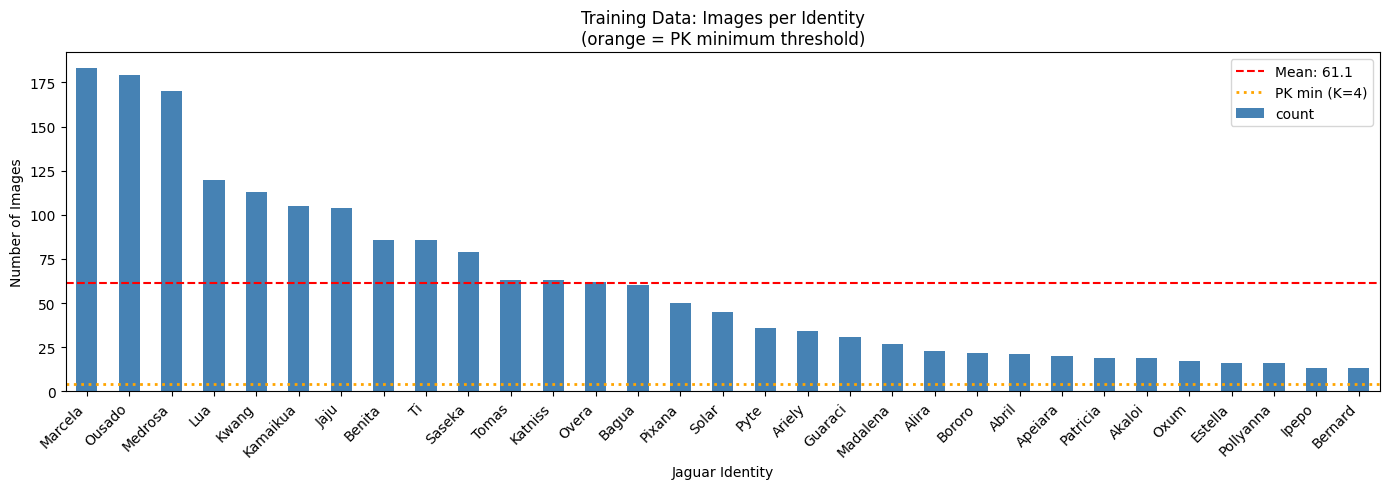

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
identity_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(y=identity_counts.mean(), color='red', linestyle='--',
           label=f'Mean: {identity_counts.mean():.1f}')
ax.axhline(y=config["K"], color='orange', linestyle=':', linewidth=2,
           label=f'PK min (K={config["K"]})')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Training Data: Images per Identity\n(orange = PK minimum threshold)')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
wandb.log({"identity_distribution": wandb.Image(fig)})
plt.show()


In [7]:
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

train_data, val_data = train_test_split(
    train_df,
    test_size    = config["val_split"],
    random_state = config["seed"],
    stratify     = train_df['ground_truth'],
)

train_identities = set(train_data['ground_truth'].unique())
val_identities   = set(val_data['ground_truth'].unique())

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")
print(f"  Identities in both sets: {len(train_identities & val_identities)} / {num_classes}")
assert train_identities == val_identities, "Some identities missing from val set!"
print("  All identities present in both sets ✓")

train_labels_enc = train_data['label_encoded'].values
val_labels_enc   = label_encoder.transform(val_data['ground_truth'].values)
val_labels_str   = val_data['ground_truth'].values

train_paths = [config["data_dir"] / "train/train" / fn
               for fn in train_data["filename"].astype(str)]
val_paths   = [config["data_dir"] / "train/train" / fn
               for fn in val_data["filename"].astype(str)]

wandb.log({
    "num_identities": num_classes,
    "train_samples":  len(train_data),
    "val_samples":    len(val_data),
})


Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)
  Identities in both sets: 31 / 31
  All identities present in both sets ✓


## 3. Load MegaDescriptor and Extract Embeddings

In [8]:
print("Loading MegaDescriptor-L-384...")
megadescriptor = timm.create_model(
    config["megadescriptor_model"],
    pretrained  = True,
    num_classes = 0,
    img_size    = config["input_size"],
)
megadescriptor.eval()
for p in megadescriptor.parameters():
    p.requires_grad = False
megadescriptor.to(device)

with torch.no_grad():
    dummy = torch.randn(1, 3, config["input_size"], config["input_size"]).to(device)
    megadescriptor_dim = megadescriptor(dummy).shape[1]

print(f"  Embedding dim: {megadescriptor_dim}")
print(f"  Parameters:    {sum(p.numel() for p in megadescriptor.parameters()):,}")
print(f"  Frozen:        True")

preprocess = transforms.Compose([
    transforms.Resize((config["input_size"], config["input_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


Loading MegaDescriptor-L-384...


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

  Embedding dim: 1536
  Parameters:    195,198,516
  Frozen:        True


In [9]:
@torch.no_grad()
def extract_embeddings(model, image_paths, batch_size=32,
                        desc="Extracting embeddings"):
    model.eval()
    all_embs = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc=desc):
        paths   = image_paths[i:i + batch_size]
        tensors = []
        for p in paths:
            try:
                tensors.append(preprocess(Image.open(p).convert("RGB")))
            except Exception as e:
                print(f"  [WARN] {p}: {e}")
                tensors.append(torch.zeros(3, config["input_size"],
                                           config["input_size"]))
        all_embs.append(
            model(torch.stack(tensors).to(device)).cpu().numpy())
    return np.vstack(all_embs)


# Train embeddings
tr_cache = config["cache_dir"] / "megadesc_train_embeddings.npz"
if tr_cache.exists():
    train_embeddings = np.load(tr_cache)["embeddings"]
    print(f"Loaded cached train embeddings: {train_embeddings.shape}")
else:
    print(f"Extracting train embeddings for {len(train_paths)} images...")
    train_embeddings = extract_embeddings(
        megadescriptor, train_paths, config["batch_size"], "Train embeddings")
    np.savez_compressed(tr_cache, embeddings=train_embeddings)
    print(f"Saved: {train_embeddings.shape}")

# Val embeddings
va_cache = config["cache_dir"] / "megadesc_val_embeddings.npz"
if va_cache.exists():
    val_embeddings = np.load(va_cache)["embeddings"]
    print(f"Loaded cached val embeddings:   {val_embeddings.shape}")
else:
    print(f"Extracting val embeddings for {len(val_paths)} images...")
    val_embeddings = extract_embeddings(
        megadescriptor, val_paths, config["batch_size"], "Val embeddings")
    np.savez_compressed(va_cache, embeddings=val_embeddings)
    print(f"Saved: {val_embeddings.shape}")


Extracting train embeddings for 1516 images...


Train embeddings:   0%|          | 0/48 [00:00<?, ?it/s]

Saved: (1516, 1536)
Extracting val embeddings for 379 images...


Val embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Saved: (379, 1536)


## 4. PK Sampler

The PK sampler constructs each batch by:
1. Randomly selecting **P identities** from the training set
2. Randomly sampling **K images** per selected identity

This guarantees that every batch has at least K anchor-positive pairs per identity,
forcing the model to train on genuine within-identity variation and meaningful
cross-identity contrasts — not just trivially easy random negatives.

For identities with fewer than K training images, we sample **with replacement**.


In [10]:
class PKSampler(Sampler):
    """
    PK Sampler: each batch contains exactly P identities × K images.

    For identities with < K images, samples with replacement.
    Yields indices into the dataset such that batch i contains
    indices [i*P*K : (i+1)*P*K] with the PK guarantee.
    """
    def __init__(self, labels: np.ndarray, P: int, K: int):
        self.labels       = np.array(labels)
        self.P            = P
        self.K            = K
        self.unique_labels = np.unique(labels)
        # Build label -> list of indices mapping
        self.label_to_idx = defaultdict(list)
        for idx, lbl in enumerate(labels):
            self.label_to_idx[lbl].append(idx)
        # Number of batches: sample all identities at least once per epoch
        n_identities    = len(self.unique_labels)
        self.n_batches  = max(1, n_identities // P)

    def __iter__(self):
        rng = np.random.default_rng()
        for _ in range(self.n_batches):
            # Sample P identities uniformly without replacement
            chosen_labels = rng.choice(
                self.unique_labels, size=self.P, replace=False)
            batch_indices = []
            for lbl in chosen_labels:
                pool    = self.label_to_idx[lbl]
                replace = len(pool) < self.K
                chosen  = rng.choice(pool, size=self.K, replace=replace)
                batch_indices.extend(chosen.tolist())
            yield from batch_indices

    def __len__(self):
        return self.n_batches * self.P * self.K


# Verify PK sampler
_sampler = PKSampler(train_labels_enc, P=config["P"], K=config["K"])
print(f"PKSampler created:")
print(f"  P={config['P']} identities × K={config['K']} images = "
      f"{config['P']*config['K']} per batch")
print(f"  Batches per epoch: {_sampler.n_batches}")
print(f"  Total samples per epoch: {len(_sampler)}")

# Check one batch has the right identity structure
_sample_indices = list(_sampler)[:config["batch_size"]]
_sample_labels  = [train_labels_enc[i] for i in _sample_indices]
_unique_in_batch = len(set(_sample_labels))
print(f"  Sample batch: {_unique_in_batch} unique identities "
      f"(expected {config['P']}) ✓")
del _sampler, _sample_indices, _sample_labels


PKSampler created:
  P=8 identities × K=4 images = 32 per batch
  Batches per epoch: 3
  Total samples per epoch: 96
  Sample batch: 8 unique identities (expected 8) ✓


## 5. Model Architecture

In [12]:
class EmbeddingProjection(nn.Module):
    """Linear → BN → ReLU → Dropout → Linear → BN. Same for all conditions."""    
    def __init__(self, input_dim, hidden_dim=512, output_dim=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
                if m.bias is not None: nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x): return self.net(x)


class ArcFaceHead(nn.Module):
    def __init__(self, embedding_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.scale  = scale
        self.cos_m  = math.cos(margin); self.sin_m = math.sin(margin)
        self.th     = math.cos(math.pi - margin)
        self.mm     = math.sin(math.pi - margin) * margin
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, emb, labels):
        emb_n = F.normalize(emb, p=2, dim=1)
        w_n   = F.normalize(self.weight, p=2, dim=1)
        cos   = torch.clamp(F.linear(emb_n, w_n), -1.0, 1.0)
        sin   = torch.sqrt(1.0 - cos ** 2)
        phi   = cos * self.cos_m - sin * self.sin_m
        phi   = torch.where(cos > self.th, phi, cos - self.mm)
        oh    = torch.zeros_like(cos).scatter_(
            1, labels.view(-1, 1).long(), 1.0)
        return (oh * phi + (1 - oh) * cos) * self.scale


class ArcFaceModel(nn.Module):
    def __init__(self, input_dim, num_classes, embedding_dim=256,
                 hidden_dim=512, margin=0.5, scale=64.0, dropout=0.3):
        super().__init__()
        self.projection = EmbeddingProjection(input_dim, hidden_dim,
                                               embedding_dim, dropout)
        self.arcface    = ArcFaceHead(embedding_dim, num_classes,
                                      margin=margin, scale=scale)

    def forward(self, x, labels):
        emb    = self.projection(x)
        logits = self.arcface(emb, labels)
        return logits, emb

    def get_embeddings(self, x):
        return F.normalize(self.projection(x), p=2, dim=1)


# Sanity check
_m = ArcFaceModel(input_dim=megadescriptor_dim, num_classes=num_classes).to(device)
_x = torch.randn(4, megadescriptor_dim).to(device)
_l = torch.zeros(4, dtype=torch.long).to(device)
_logits, _emb = _m(_x, _l)
print(f"ArcFaceModel sanity check: logits={_logits.shape}, emb={_emb.shape}")
print(f"  Params: {sum(p.numel() for p in _m.parameters()):,}")
del _m, _x, _l, _logits, _emb


ArcFaceModel sanity check: logits=torch.Size([4, 31]), emb=torch.Size([4, 256])
  Params: 927,744


## 6. Batch-Hard Triplet Loss

For each anchor in the batch we find:
- **Hardest positive**: the same-identity sample with the **largest** embedding distance
- **Hardest negative**: the different-identity sample with the **smallest** embedding distance

```
triplet_loss = mean( max(0, d(a, p_hard) − d(a, n_hard) + margin) )
```

We also track the **triplet violation rate** — the fraction of anchors where
the hard triplet constraint is active (loss > 0). This should decrease as
training progresses, indicating the model is learning a better-separated space.


In [13]:
class BatchHardTripletLoss(nn.Module):
    """
    Batch-Hard Triplet Loss.

    For each anchor:
      - hardest positive = max distance among same-label samples
      - hardest negative = min distance among different-label samples
    Returns (loss, violation_rate) where violation_rate is the fraction
    of anchors with an active triplet (loss > 0 before clamping).
    """
    def __init__(self, margin: float = 0.3):
        super().__init__()
        self.margin = margin

    def forward(self, embeddings: torch.Tensor,
                labels: torch.Tensor):
        # L2-normalise embeddings
        emb    = F.normalize(embeddings, p=2, dim=1)
        # Pairwise squared Euclidean distances
        dot    = emb @ emb.T
        sq_n   = (emb ** 2).sum(dim=1, keepdim=True)
        dist2  = sq_n + sq_n.T - 2 * dot
        dist   = torch.sqrt(torch.clamp(dist2, min=1e-12))  # (B, B)

        B      = labels.size(0)
        labels = labels.view(-1)

        # Masks
        same   = labels.unsqueeze(0) == labels.unsqueeze(1)   # (B, B)
        diff   = ~same
        eye    = torch.eye(B, dtype=torch.bool, device=dist.device)
        pos_mask = same & ~eye   # same identity, exclude self
        neg_mask = diff          # different identity

        # Hardest positive: max distance within same identity
        # For anchors with no positives in batch, use 0
        dist_pos = dist * pos_mask.float()
        hard_pos = dist_pos.max(dim=1)[0]   # (B,)

        # Hardest negative: min distance across different identities
        dist_neg = dist + (~neg_mask).float() * 1e9
        hard_neg = dist_neg.min(dim=1)[0]   # (B,)

        triplet  = torch.clamp(hard_pos - hard_neg + self.margin, min=0.0)
        loss     = triplet.mean()

        # Violation rate: fraction with active triplet (before clamping)
        raw      = hard_pos - hard_neg + self.margin
        violation_rate = (raw > 0).float().mean().item()

        return loss, violation_rate


# Sanity check
_loss_fn = BatchHardTripletLoss(margin=0.3)
_emb     = F.normalize(torch.randn(32, 256), p=2, dim=1).to(device)
_labels  = torch.repeat_interleave(torch.arange(8), 4).to(device)
_loss, _vr = _loss_fn(_emb, _labels)
print(f"BatchHardTripletLoss sanity check:")
print(f"  loss={_loss.item():.4f}  violation_rate={_vr:.4f}")
del _loss_fn, _emb, _labels, _loss, _vr


BatchHardTripletLoss sanity check:
  loss=0.4234  violation_rate=1.0000


## 7. Training Utilities

In [14]:
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels     = torch.LongTensor(labels)
    def __len__(self):          return len(self.labels)
    def __getitem__(self, idx): return self.embeddings[idx], self.labels[idx]


def make_loader(embeddings, labels, batch_strategy: str,
                P: int, K: int, batch_size: int) -> DataLoader:
    """Build a DataLoader using either random or PK batch strategy."""    
    dataset = EmbeddingDataset(embeddings, labels)
    if batch_strategy == "pk":
        sampler = PKSampler(labels, P=P, K=K)
        return DataLoader(dataset, batch_size=batch_size,
                          sampler=sampler, num_workers=0, drop_last=True)
    else:
        return DataLoader(dataset, batch_size=batch_size,
                          shuffle=True, num_workers=0, drop_last=True)


def train_epoch(model, loader, criterion_arcface,
                criterion_triplet, triplet_lambda: float,
                optimizer, device):
    """
    One training epoch.
    Returns (avg_loss, avg_arcface_loss, avg_triplet_loss,
             avg_acc, avg_violation_rate).
    """
    model.train()
    total_loss, total_arc, total_tri = 0.0, 0.0, 0.0
    correct, total, total_vr         = 0, 0, 0.0

    pbar = tqdm(loader, desc='Train', leave=False)
    for emb, labels in pbar:
        emb, labels = emb.to(device), labels.to(device)
        logits, projected = model(emb, labels)

        arc_loss = criterion_arcface(logits, labels)

        if triplet_lambda > 0.0:
            tri_loss, vr = criterion_triplet(projected, labels)
            loss         = arc_loss + triplet_lambda * tri_loss
        else:
            tri_loss, vr = torch.tensor(0.0), 0.0
            loss         = arc_loss

        optimizer.zero_grad(); loss.backward(); optimizer.step()

        bs           = labels.size(0)
        total_loss  += loss.item()
        total_arc   += arc_loss.item()
        total_tri   += tri_loss.item() if triplet_lambda > 0 else 0.0
        correct     += (logits.argmax(1) == labels).sum().item()
        total       += bs
        total_vr    += vr

        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            arc=f"{arc_loss.item():.4f}",
            tri=f"{tri_loss.item() if triplet_lambda > 0 else 0.0:.4f}",
            acc=f"{100.*correct/total:.1f}%",
        )

    n = len(loader)
    return (total_loss/n, total_arc/n, total_tri/n,
            100.*correct/total, total_vr/n)


def validate_epoch(model, loader, criterion_arcface, device):
    model.eval(); total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        pbar = tqdm(loader, desc='Val', leave=False)
        for emb, labels in pbar:
            emb, labels = emb.to(device), labels.to(device)
            logits, _   = model(emb, labels)
            loss        = criterion_arcface(logits, labels)
            total_loss += loss.item()
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)
    return total_loss / len(loader), 100. * correct / total


def compute_validation_map(model, embeddings, labels_str):
    model.eval()
    with torch.no_grad():
        emb = model.get_embeddings(
            torch.FloatTensor(embeddings).to(device)).cpu().numpy()
    return _map_from_embeddings(emb, labels_str)


def _map_from_embeddings(emb, labels):
    emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)
    sim = emb @ emb.T; np.fill_diagonal(sim, -1)
    id_aps = defaultdict(list)
    for q in range(len(labels)):
        ql       = labels[q]
        is_match = (labels == ql).astype(int); is_match[q] = 0
        n_pos    = is_match.sum()
        if n_pos == 0: continue
        order    = np.argsort(-sim[q]); sm = is_match[order]
        cum      = np.cumsum(sm); prec = cum / np.arange(1, len(sm)+1)
        id_aps[ql].append(float(np.sum(prec * sm) / n_pos))
    return float(np.mean([np.mean(v) for v in id_aps.values()]))


print("Training utilities defined.")


Training utilities defined.


## 8. Training Loop — All Four Conditions

Each condition trains an **independent** model from the same random seed,
on the same pre-extracted embeddings, with identical hyperparameters except
for the batch strategy and loss function.

Checkpoints are saved to `/kaggle/working/checkpoints/{condition_name}_best.pth`.


In [15]:
condition_results   = {}   # name -> result dict
condition_ft_embs   = {}   # name -> fine-tuned val embeddings

criterion_arcface = nn.CrossEntropyLoss()
criterion_triplet = BatchHardTripletLoss(margin=config["triplet_margin"])

# Validation loader is always random (same for all conditions)
val_dataset = EmbeddingDataset(val_embeddings, val_labels_enc)
val_loader  = DataLoader(val_dataset, batch_size=config["batch_size"],
                          shuffle=False, num_workers=0)

for cond in CONDITION_CONFIGS:
    cname = cond["name"]
    print("\n" + "="*70)
    print(f"CONDITION: {cname}")
    print(f"  {cond['description']}")
    print("="*70)

    ckpt_path = config["checkpoint_dir"] / f"{cname}_best.pth"

    # Build train loader
    train_loader = make_loader(
        train_embeddings, train_labels_enc,
        batch_strategy = cond["batch_strategy"],
        P=config["P"], K=config["K"],
        batch_size=config["batch_size"],
    )
    print(f"  Train loader: {len(train_loader)} batches "
          f"({cond['batch_strategy'].upper()} strategy)")

    # Initialise model
    set_seed(config["seed"])
    model = ArcFaceModel(
        input_dim     = megadescriptor_dim,
        num_classes   = num_classes,
        embedding_dim = config["embedding_dim"],
        hidden_dim    = config["hidden_dim"],
        margin        = config["arcface_margin"],
        scale         = config["arcface_scale"],
        dropout       = config["dropout"],
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(),
                                   lr=config["learning_rate"],
                                   weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5)

    history = {k: [] for k in [
        'train_loss', 'train_arc_loss', 'train_tri_loss',
        'train_acc', 'train_vr',
        'val_loss', 'val_acc', 'val_map', 'lr'
    ]}

    best_val_loss    = float('inf')
    best_map         = 0.0
    best_epoch       = 0
    patience_counter = 0

    # Epoch loop
    for epoch in range(config["num_epochs"]):
        tr_loss, tr_arc, tr_tri, tr_acc, tr_vr = train_epoch(
            model, train_loader,
            criterion_arcface, criterion_triplet,
            cond["triplet_lambda"], optimizer, device)

        va_loss, va_acc = validate_epoch(
            model, val_loader, criterion_arcface, device)
        va_map = compute_validation_map(
            model, val_embeddings, val_labels_str)

        scheduler.step(va_loss)
        lr = optimizer.param_groups[0]['lr']

        for k, v in zip(
            ['train_loss','train_arc_loss','train_tri_loss',
             'train_acc','train_vr','val_loss','val_acc','val_map','lr'],
            [tr_loss, tr_arc, tr_tri, tr_acc, tr_vr,
             va_loss, va_acc, va_map, lr]):
            history[k].append(v)

        wandb.log({
            f"{cname}/epoch":          epoch + 1,
            f"{cname}/train_loss":     tr_loss,
            f"{cname}/train_arc_loss": tr_arc,
            f"{cname}/train_tri_loss": tr_tri,
            f"{cname}/train_acc":      tr_acc,
            f"{cname}/train_vr":       tr_vr,
            f"{cname}/val_loss":       va_loss,
            f"{cname}/val_acc":        va_acc,
            f"{cname}/val_map":        va_map,
            f"{cname}/lr":             lr,
        })

        print(f"  Epoch {epoch+1:3d}/{config['num_epochs']} | "
              f"TrLoss:{tr_loss:.4f} Arc:{tr_arc:.4f} Tri:{tr_tri:.4f} "
              f"VR:{tr_vr:.2f} | VaLoss:{va_loss:.4f} VamAP:{va_map:.4f} "
              f"| LR:{lr:.2e}")

        if va_loss < best_val_loss:
            best_val_loss    = va_loss
            best_map         = va_map
            best_epoch       = epoch + 1
            patience_counter = 0
            torch.save({
                'epoch':              best_epoch,
                'model_state_dict':   model.state_dict(),
                'val_loss':           float(best_val_loss),
                'val_map':            float(best_map),
                'condition_name':     cname,
                'megadescriptor_dim': megadescriptor_dim,
                'num_classes':        num_classes,
                'config':             {k: str(v) if isinstance(v, Path) else v
                                       for k, v in config.items()},
            }, ckpt_path)
            print(f"    ✓ Saved best checkpoint (epoch {best_epoch}, "
                  f"mAP={best_map:.4f}) → {ckpt_path}")
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    # Reload best checkpoint
    ckpt       = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    for p in model.parameters():
        p.requires_grad = False

    # Fine-tuned val embeddings for diversity analysis
    with torch.no_grad():
        ft_emb = model.get_embeddings(
            torch.FloatTensor(val_embeddings).to(device)).cpu().numpy()
    condition_ft_embs[cname] = ft_emb

    # Per-identity AP
    ft_norm  = ft_emb / (np.linalg.norm(ft_emb, axis=1, keepdims=True) + 1e-12)
    sim_mat  = ft_norm @ ft_norm.T; np.fill_diagonal(sim_mat, -1)
    per_id_ap = defaultdict(list)
    for q in range(len(val_labels_str)):
        ql       = val_labels_str[q]
        is_match = (val_labels_str == ql).astype(int); is_match[q] = 0
        n_pos    = is_match.sum()
        if n_pos == 0: continue
        order    = np.argsort(-sim_mat[q]); sm = is_match[order]
        cum      = np.cumsum(sm); prec = cum / np.arange(1, len(sm)+1)
        per_id_ap[ql].append(float(np.sum(prec * sm) / n_pos))
    per_id_mean_ap = {k: float(np.mean(v)) for k, v in per_id_ap.items()}

    condition_results[cname] = {
        'best_map':        best_map,
        'best_epoch':      best_epoch,
        'best_val_loss':   best_val_loss,
        'history':         history,
        'ckpt_path':       str(ckpt_path),
        'per_id_ap':       per_id_mean_ap,
        'description':     cond['description'],
        'batch_strategy':  cond['batch_strategy'],
        'loss_type':       cond['loss_type'],
        'triplet_lambda':  cond['triplet_lambda'],
    }

    wandb.log({
        f"{cname}/best_val_map": best_map,
        f"{cname}/best_epoch":   best_epoch,
    })
    print(f"\n  ✓ {cname}: best_map={best_map:.4f} @ epoch {best_epoch}")

print("\n" + "="*70)
print("ALL CONDITIONS TRAINED")
print("="*70)
for name, r in condition_results.items():
    print(f"  {name:40s} | mAP: {r['best_map']:.4f} | Epoch: {r['best_epoch']}")



CONDITION: A_Random_ArcFace
  Baseline: random batch + ArcFace only
  Train loader: 47 batches (RANDOM strategy)


Train:   0%|          | 0/47 [00:00<?, ?it/s]

Val:   0%|          | 0/12 [00:00<?, ?it/s]

  Epoch   1/50 | TrLoss:36.5249 Arc:36.5249 Tri:0.0000 VR:0.00 | VaLoss:31.6846 VamAP:0.3343 | LR:1.00e-04
    ✓ Saved best checkpoint (epoch 1, mAP=0.3343) → /kaggle/working/checkpoints/A_Random_ArcFace_best.pth


Train:   0%|          | 0/47 [00:00<?, ?it/s]

...

Val:   0%|          | 0/12 [00:00<?, ?it/s]

  Epoch  49/50 | TrLoss:29.0948 Arc:28.6841 Tri:0.4107 VR:1.00 | VaLoss:27.1122 VamAP:0.3732 | LR:1.00e-04
    ✓ Saved best checkpoint (epoch 49, mAP=0.3732) → /kaggle/working/checkpoints/D_PK_ArcFace_Triplet_10_best.pth


Train:   0%|          | 0/3 [00:00<?, ?it/s]

Val:   0%|          | 0/12 [00:00<?, ?it/s]

  Epoch  50/50 | TrLoss:27.6884 Arc:27.3067 Tri:0.3816 VR:0.95 | VaLoss:26.9236 VamAP:0.3744 | LR:1.00e-04
    ✓ Saved best checkpoint (epoch 50, mAP=0.3744) → /kaggle/working/checkpoints/D_PK_ArcFace_Triplet_10_best.pth

  ✓ D_PK_ArcFace_Triplet_10: best_map=0.3744 @ epoch 50

ALL CONDITIONS TRAINED
  A_Random_ArcFace                         | mAP: 0.7793 | Epoch: 50
  B_PK_ArcFace                             | mAP: 0.3719 | Epoch: 50
  C_PK_ArcFace_Triplet_05                  | mAP: 0.3727 | Epoch: 50
  D_PK_ArcFace_Triplet_10                  | mAP: 0.3744 | Epoch: 50


## 9. Training Curves

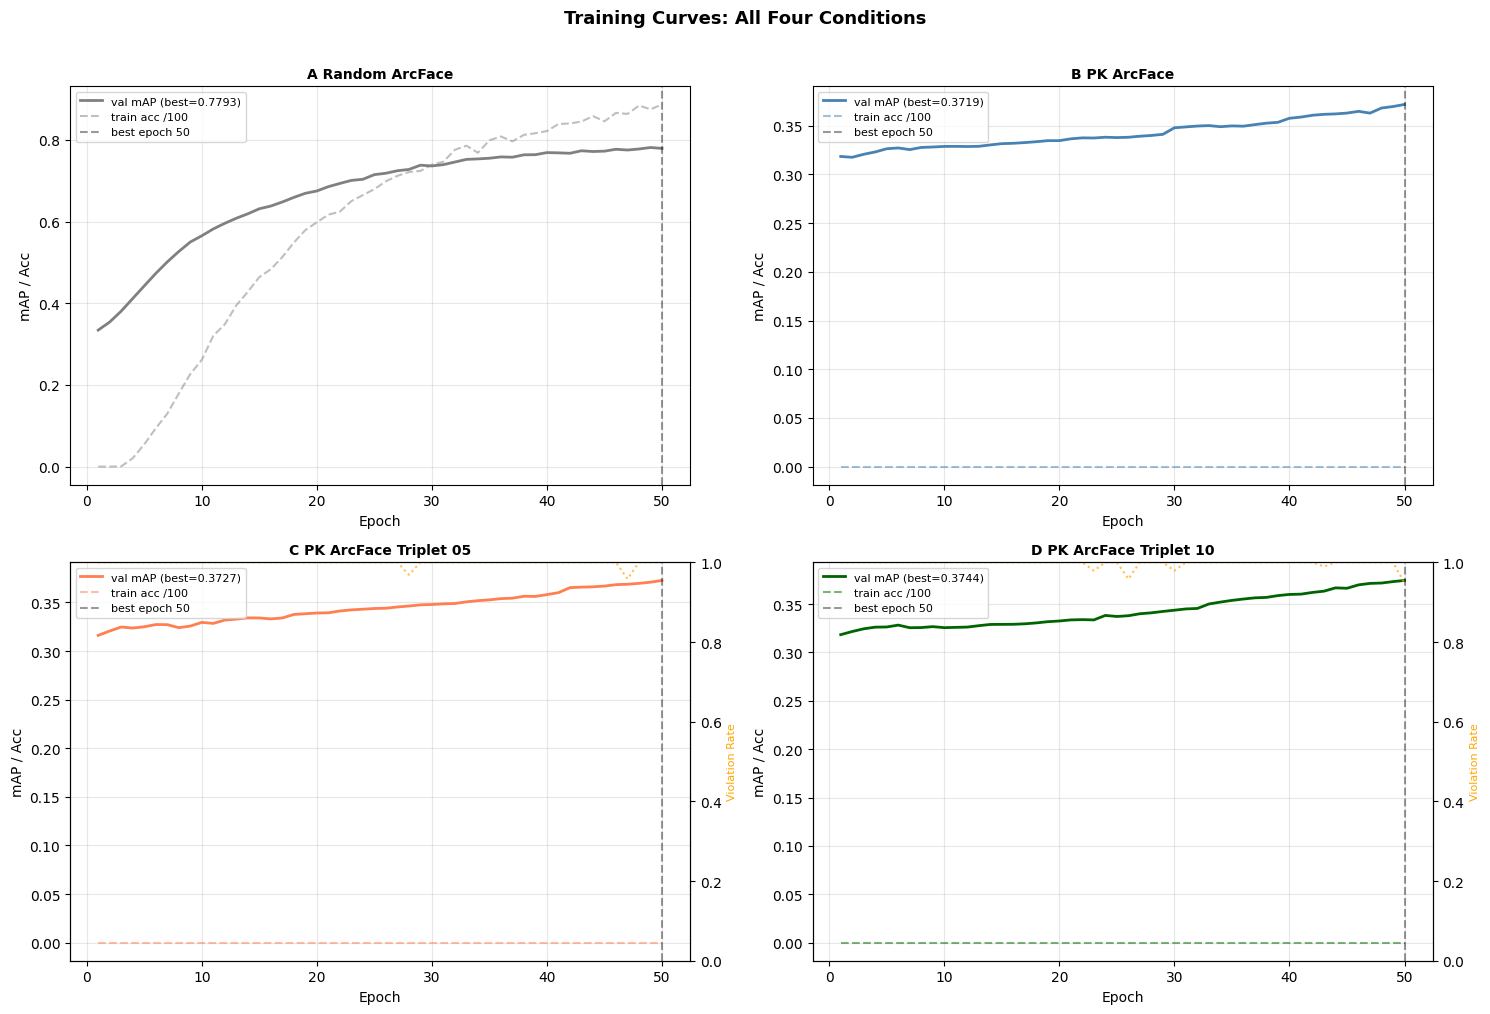

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
colors = ['gray', 'steelblue', 'coral', 'darkgreen']

for ax, (cname, r), color in zip(axes.flat,
                                   condition_results.items(), colors):
    h      = r['history']
    epochs = range(1, len(h['val_map']) + 1)
    ax.plot(epochs, h['val_map'],       color=color, linewidth=2,
            label=f"val mAP (best={r['best_map']:.4f})")
    ax.plot(epochs, [v/100 for v in h['train_acc']], color=color,
            linestyle='--', alpha=0.5, label='train acc /100')
    if any(v > 0 for v in h['train_vr']):
        ax2 = ax.twinx()
        ax2.plot(epochs, h['train_vr'], color='orange', linestyle=':',
                 alpha=0.7, label='triplet violation rate')
        ax2.set_ylabel('Violation Rate', color='orange', fontsize=8)
        ax2.set_ylim(0, 1)
    ax.axvline(x=r['best_epoch'], color='black', linestyle='--',
               alpha=0.4, label=f"best epoch {r['best_epoch']}")
    ax.set_title(cname.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('mAP / Acc')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Training Curves: All Four Conditions', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(config['checkpoint_dir'] / 'training_curves.png',
            dpi=150, bbox_inches='tight')
wandb.log({"results/training_curves": wandb.Image(fig)})
plt.show()


## 10. Triplet Violation Rate Analysis

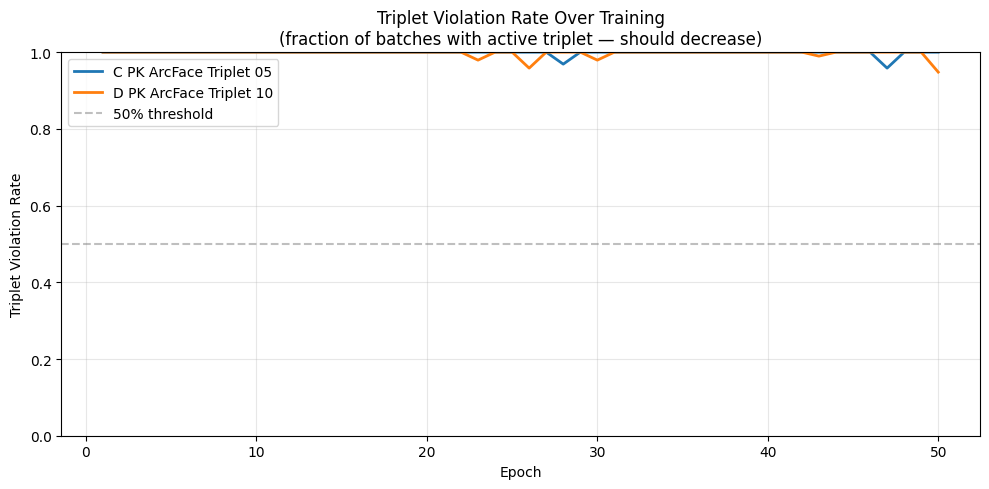

Final (last epoch) triplet violation rates:
  C_PK_ArcFace_Triplet_05: 1.0000
    (1.0 = all triplets active; 0.0 = fully separated)
  D_PK_ArcFace_Triplet_10: 0.9479
    (1.0 = all triplets active; 0.0 = fully separated)


In [17]:
# Plot triplet violation rate over epochs for PK+Triplet conditions
triplet_conds = [
    (name, r) for name, r in condition_results.items()
    if r['loss_type'] == 'arcface_triplet'
]

if triplet_conds:
    fig, ax = plt.subplots(figsize=(10, 5))
    for cname, r in triplet_conds:
        vr     = r['history']['train_vr']
        epochs = range(1, len(vr) + 1)
        ax.plot(epochs, vr, linewidth=2, label=cname.replace('_', ' '))
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Triplet Violation Rate')
    ax.set_title('Triplet Violation Rate Over Training\n'
                 '(fraction of batches with active triplet — should decrease)')
    ax.set_ylim(0, 1)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5,
               label='50% threshold')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    wandb.log({"results/violation_rate": wandb.Image(fig)})
    plt.show()

    # Report final violation rates
    print("Final (last epoch) triplet violation rates:")
    for cname, r in triplet_conds:
        final_vr = r['history']['train_vr'][-1]
        print(f"  {cname}: {final_vr:.4f}")
        print(f"    (1.0 = all triplets active; 0.0 = fully separated)")
else:
    print("No triplet conditions found.")


## 11. Results Summary

In [18]:
baseline_name = "A_Random_ArcFace"
baseline_map  = condition_results[baseline_name]['best_map']
best_name     = max(condition_results, key=lambda n: condition_results[n]['best_map'])
best_map_val  = condition_results[best_name]['best_map']

print("=" * 72)
print(f"{'Condition':42s} | {'mAP':>6} | {'vs Baseline':>11} | Epoch")
print("-" * 72)
for cname, r in condition_results.items():
    gain   = r['best_map'] - baseline_map
    marker = "  << BEST"    if cname == best_name else ""
    note   = "  (baseline)" if cname == baseline_name else ""
    print(f"  {cname:40s} | {r['best_map']:.4f} | "
          f"{gain:+.4f}     | {r['best_epoch']:>5}{marker}{note}")
print("=" * 72)

# Decompose: how much from PK alone vs how much from triplet
pk_only_map    = condition_results["B_PK_ArcFace"]["best_map"]
pk_sampling_gain = pk_only_map - baseline_map
best_triplet_gain = best_map_val - pk_only_map

print(f"\nEffect decomposition:")
print(f"  PK sampling alone (B vs A):          {pk_sampling_gain:+.4f}")
print(f"  Best triplet on top of PK (best vs B): {best_triplet_gain:+.4f}")
print(f"  Total gain (best vs baseline):          {best_map_val - baseline_map:+.4f}")

wandb.log({
    "results/baseline_map":         baseline_map,
    "results/best_map":             best_map_val,
    "results/best_condition":       best_name,
    "results/pk_sampling_gain":     pk_sampling_gain,
    "results/best_triplet_gain":    best_triplet_gain,
    "results/total_gain":           best_map_val - baseline_map,
})


Condition                                  |    mAP | vs Baseline | Epoch
------------------------------------------------------------------------
  A_Random_ArcFace                         | 0.7793 | +0.0000     |    50  << BEST  (baseline)
  B_PK_ArcFace                             | 0.3719 | -0.4074     |    50
  C_PK_ArcFace_Triplet_05                  | 0.3727 | -0.4066     |    50
  D_PK_ArcFace_Triplet_10                  | 0.3744 | -0.4049     |    50

Effect decomposition:
  PK sampling alone (B vs A):          -0.4074
  Best triplet on top of PK (best vs B): +0.4074
  Total gain (best vs baseline):          +0.0000


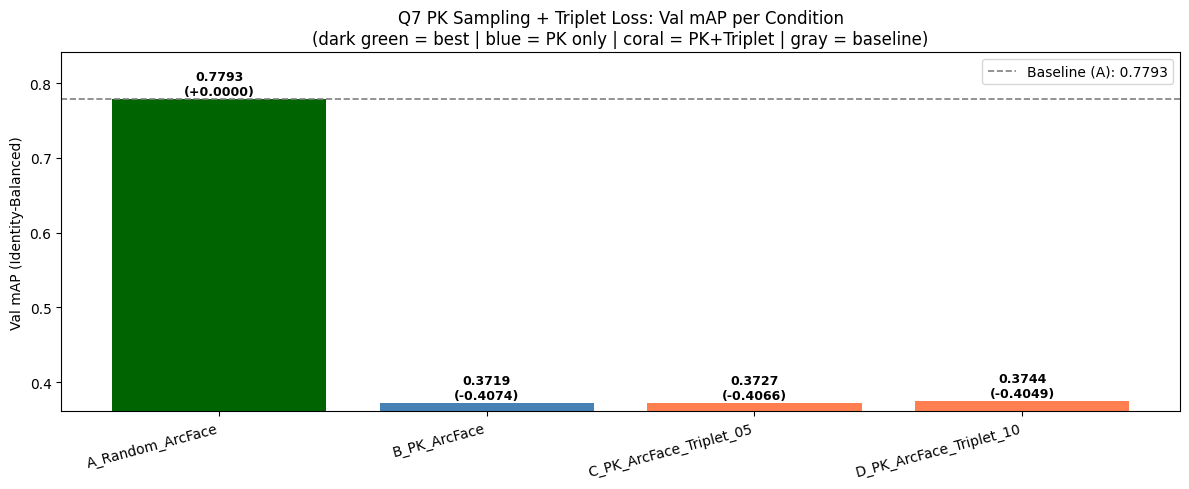

In [19]:
names  = list(condition_results.keys())
maps   = [condition_results[n]['best_map'] for n in names]
colors = []
for n in names:
    if n == best_name:          colors.append('darkgreen')
    elif n == baseline_name:    colors.append('gray')
    elif 'Triplet' in n:        colors.append('coral')
    else:                       colors.append('steelblue')

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names, maps, color=colors)
for bar, val, n in zip(bars, maps, names):
    gain = val - baseline_map
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f"{val:.4f}\n({gain:+.4f})",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(y=baseline_map, color='gray', linestyle='--', linewidth=1.2,
           label=f"Baseline (A): {baseline_map:.4f}")
ax.set_ylim(min(maps)*0.97, max(maps)*1.08)
ax.set_ylabel('Val mAP (Identity-Balanced)')
ax.set_title('PK Sampling + Triplet Loss: Val mAP per Condition\n'
             '(dark green = best | blue = PK only | coral = PK+Triplet | gray = baseline)')
ax.legend()
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
wandb.log({"results/comparison_bar_chart": wandb.Image(fig)})
plt.savefig(config['checkpoint_dir'] / 'condition_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 12. Per-Identity Analysis

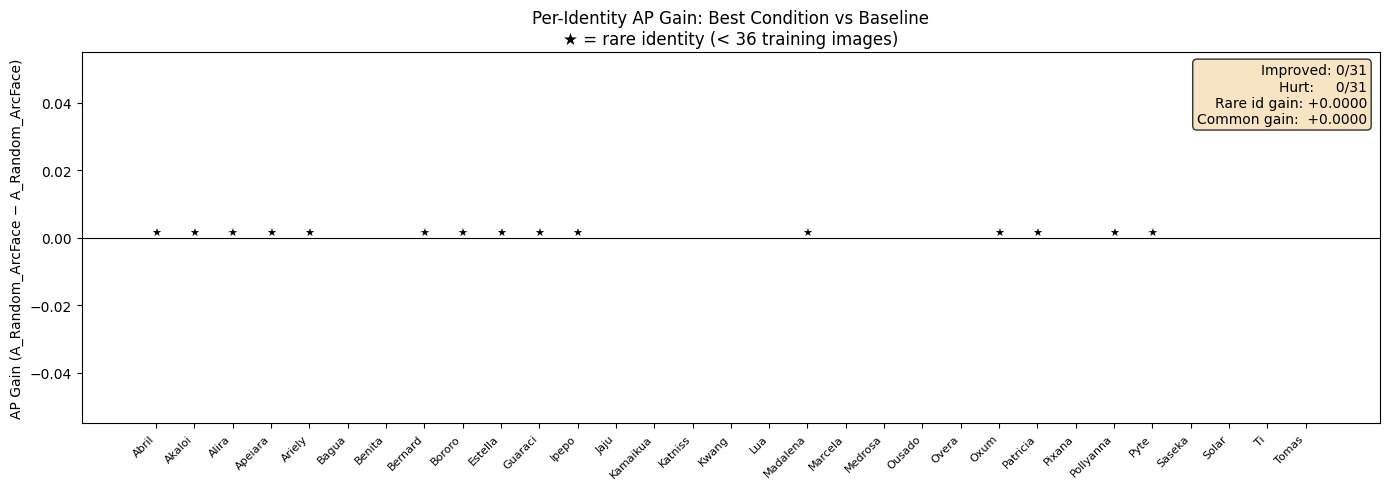

Per-identity summary (A_Random_ArcFace vs A_Random_ArcFace):
  Improved: 0/31
  Hurt:     0/31
  Mean gain on rare identities (★):   +0.0000
  Mean gain on common identities:      +0.0000
  Hypothesis: PK sampling helps rare identities more
  Evidence:   NOT SUPPORTED


In [20]:
# Compare best condition vs baseline per identity
baseline_per_id = condition_results[baseline_name]['per_id_ap']
best_per_id     = condition_results[best_name]['per_id_ap']

identities = sorted(best_per_id.keys())
gains       = [best_per_id[i] - baseline_per_id.get(i, 0.0) for i in identities]

# Annotate rare identities (< median training count)
train_counts   = train_data['ground_truth'].value_counts()
median_count   = train_counts.median()
rare_ids       = set(train_counts[train_counts < median_count].index)

n_improved  = sum(1 for g in gains if g > 0.001)
n_hurt      = sum(1 for g in gains if g < -0.001)
rare_gains  = [g for i, g in zip(identities, gains) if i in rare_ids]
common_gains = [g for i, g in zip(identities, gains) if i not in rare_ids]

fig, ax = plt.subplots(figsize=(14, 5))
colors  = ['green' if g > 0.001 else 'red' if g < -0.001 else 'lightgray'
           for g in gains]
bars    = ax.bar(range(len(identities)), gains, color=colors)

# Mark rare identities with an X
for idx, (ident, gain) in enumerate(zip(identities, gains)):
    if ident in rare_ids:
        ax.text(idx, gain + np.sign(gain)*0.005, '★',
                ha='center', va='bottom' if gain >= 0 else 'top',
                fontsize=8, color='black')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(len(identities)))
ax.set_xticklabels(identities, rotation=45, ha='right', fontsize=8)
ax.set_ylabel(f'AP Gain ({best_name} − {baseline_name})')
ax.set_title(f'Per-Identity AP Gain: Best Condition vs Baseline\n'
             f'★ = rare identity (< {median_count:.0f} training images)')
ax.text(0.99, 0.97,
        f'Improved: {n_improved}/{len(identities)}\n'
        f'Hurt:     {n_hurt}/{len(identities)}\n'
        f'Rare id gain: {np.mean(rare_gains):+.4f}\n'
        f'Common gain:  {np.mean(common_gains):+.4f}',
        transform=ax.transAxes, va='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
wandb.log({"results/per_identity_gain": wandb.Image(fig)})
plt.show()

print(f"Per-identity summary ({best_name} vs {baseline_name}):")
print(f"  Improved: {n_improved}/{len(identities)}")
print(f"  Hurt:     {n_hurt}/{len(identities)}")
print(f"  Mean gain on rare identities (★):   {np.mean(rare_gains):+.4f}")
print(f"  Mean gain on common identities:      {np.mean(common_gains):+.4f}")
print(f"  Hypothesis: PK sampling helps rare identities more")
print(f"  Evidence:   {'SUPPORTED' if np.mean(rare_gains) > np.mean(common_gains) else 'NOT SUPPORTED'}")

wandb.log({
    "results/identities_improved":   n_improved,
    "results/identities_hurt":       n_hurt,
    "results/rare_id_mean_gain":     float(np.mean(rare_gains)),
    "results/common_id_mean_gain":   float(np.mean(common_gains)),
})


## 13. Embedding Space Visualisation

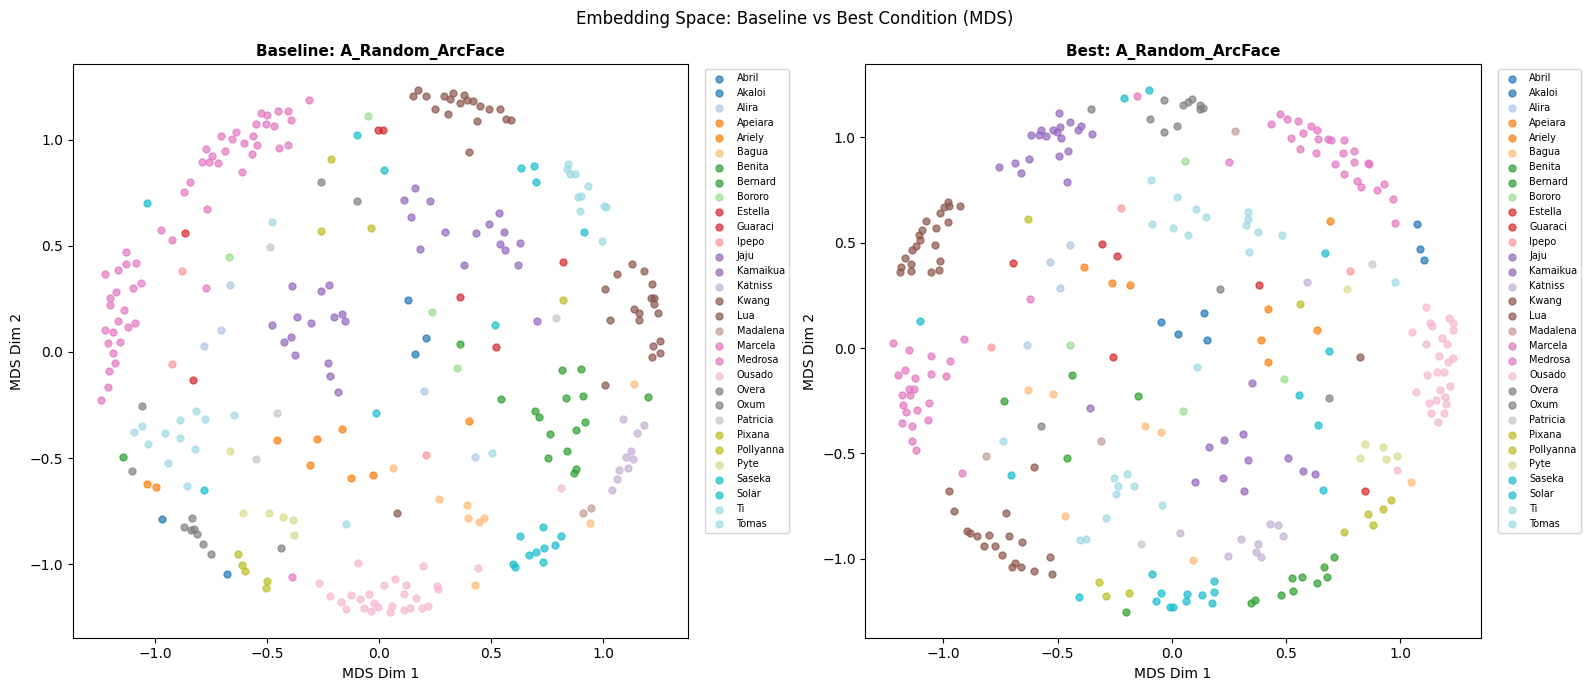

In [21]:
# Compare embedding space of baseline vs best condition using MDS
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, cname, title in zip(
    axes,
    [baseline_name, best_name],
    [f"Baseline: {baseline_name}", f"Best: {best_name}"]
):
    emb    = condition_ft_embs[cname]
    # Subsample for speed
    n_plot = min(300, len(emb))
    idx    = np.random.choice(len(emb), n_plot, replace=False)
    e_sub  = emb[idx]
    l_sub  = val_labels_str[idx]

    # MDS on cosine distances
    e_norm = e_sub / (np.linalg.norm(e_sub, axis=1, keepdims=True) + 1e-12)
    cos    = np.clip(e_norm @ e_norm.T, -1, 1)
    dist   = np.arccos(cos)
    mds    = MDS(n_components=2, dissimilarity='precomputed',
                 random_state=RANDOM_SEED, normalized_stress='auto')
    coords = mds.fit_transform(dist)

    unique_labels = np.unique(l_sub)
    cmap          = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    for lbl, c in zip(unique_labels, cmap):
        mask = l_sub == lbl
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   color=c, label=lbl, alpha=0.7, s=25)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('MDS Dim 1'); ax.set_ylabel('MDS Dim 2')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

plt.suptitle('Embedding Space: Baseline vs Best Condition (MDS)', fontsize=12)
plt.tight_layout()
wandb.log({"results/embedding_mds_comparison": wandb.Image(fig)})
plt.show()


## 14. Generate Competition Submission

In [22]:
test_pairs_df = pd.read_csv(config["data_dir"] / "test.csv")
test_images   = sorted(
    set(test_pairs_df['query_image'].unique()) |
    set(test_pairs_df['gallery_image'].unique()))
test_paths = [config["data_dir"] / "test/test" / fn for fn in test_images]

print(f"Test pairs:     {len(test_pairs_df)}")
print(f"Unique images:  {len(test_images)}")
print(f"Using condition: {best_name}  (mAP={best_map_val:.4f})")

# Extract test backbone embeddings
te_cache = config["cache_dir"] / "megadesc_test_embeddings.npz"
if te_cache.exists():
    test_backbone_embs = np.load(te_cache)["embeddings"]
    print(f"Loaded cached test embeddings: {test_backbone_embs.shape}")
else:
    print(f"Extracting test backbone embeddings for {len(test_images)} images...")
    test_backbone_embs = extract_embeddings(
        megadescriptor, test_paths, config["batch_size"], "Test embeddings")
    np.savez_compressed(te_cache, embeddings=test_backbone_embs)
    print(f"Saved: {test_backbone_embs.shape}")

# Load best checkpoint and project test embeddings
best_ckpt = torch.load(
    config["checkpoint_dir"] / f"{best_name}_best.pth",
    map_location=device, weights_only=False)

best_model = ArcFaceModel(
    input_dim     = best_ckpt['megadescriptor_dim'],
    num_classes   = best_ckpt['num_classes'],
    embedding_dim = config["embedding_dim"],
    hidden_dim    = config["hidden_dim"],
    margin        = config["arcface_margin"],
    scale         = config["arcface_scale"],
    dropout       = config["dropout"],
).to(device)
best_model.load_state_dict(best_ckpt['model_state_dict'])
best_model.eval()

with torch.no_grad():
    test_emb = best_model.get_embeddings(
        torch.FloatTensor(test_backbone_embs).to(device)).cpu().numpy()
test_emb = test_emb / (np.linalg.norm(test_emb, axis=1, keepdims=True) + 1e-12)
img_to_emb = dict(zip(test_images, test_emb))
print(f"Test embeddings projected: {test_emb.shape}")


Test pairs:     137270
Unique images:  371
Using condition: A_Random_ArcFace  (mAP=0.7793)
Extracting test backbone embeddings for 371 images...


Test embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Saved: (371, 1536)
Test embeddings projected: (371, 256)


In [23]:
similarities = []
for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df),
                   desc="Computing similarities"):
    q = img_to_emb[row['query_image']]
    g = img_to_emb[row['gallery_image']]
    similarities.append(float(np.dot(q, g)))

similarities = np.clip(np.array(similarities), 0.0, 1.0)
print(f"Similarity stats: min={similarities.min():.4f}  "
      f"max={similarities.max():.4f}  mean={similarities.mean():.4f}")

submission_df = pd.DataFrame({'row_id':     test_pairs_df['row_id'],
                               'similarity': similarities})
submission_path = config['checkpoint_dir'] / 'submission.csv'
submission_df.to_csv(submission_path, index=False)
submission_df.to_csv('/kaggle/working/submission.csv', index=False)
print(f"Submission saved: {submission_path}")
print(submission_df.head(10))


Computing similarities:   0%|          | 0/137270 [00:00<?, ?it/s]

Similarity stats: min=0.0000  max=0.9948  mean=0.0609
Submission saved: /kaggle/working/checkpoints/submission.csv
   row_id  similarity
0       0    0.666780
1       1    0.000000
2       2    0.000000
3       3    0.000000
4       4    0.000000
5       5    0.000000
6       6    0.050577
7       7    0.000000
8       8    0.000000
9       9    0.077109


## 15. Save Artifacts to W&B

In [24]:
# Results table
rows = []
for cname, r in condition_results.items():
    rows.append({
        "condition":       cname,
        "batch_strategy":  r['batch_strategy'],
        "loss_type":       r['loss_type'],
        "triplet_lambda":  r['triplet_lambda'],
        "val_map":         round(r['best_map'], 6),
        "gain_vs_baseline": round(r['best_map'] - baseline_map, 6),
        "best_epoch":      r['best_epoch'],
    })
wandb.log({"results/conditions_table": wandb.Table(
    dataframe=pd.DataFrame(rows))})

# Best checkpoint artifact
art = wandb.Artifact("pk-triplet-best-model", type="model",
    description=f"Best model: {best_name} (mAP={best_map_val:.4f})")
art.add_file(str(config['checkpoint_dir'] / f'{best_name}_best.pth'))
wandb.log_artifact(art)

# Submission artifact
sub_art = wandb.Artifact("submission", type="submission",
    description=f"PK+Triplet submission | condition={best_name}")
sub_art.add_file(str(submission_path))
wandb.log_artifact(sub_art)

wandb.finish()
print("W&B run completed.")
print(f"Best checkpoint: {config['checkpoint_dir'] / f'{best_name}_best.pth'}")


A_Random_ArcFace/best_epoch,▁
A_Random_ArcFace/best_val_map,▁
A_Random_ArcFace/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
A_Random_ArcFace/lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
A_Random_ArcFace/train_acc,▁▁▁▁▂▂▃▃▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████
A_Random_ArcFace/train_arc_loss,█▇▆▆▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
A_Random_ArcFace/train_loss,█▇▆▆▅▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
A_Random_ArcFace/train_tri_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
A_Random_ArcFace/train_vr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
A_Random_ArcFace/val_acc,▁▁▂▂▃▄▄▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████
+50,...


W&B run completed.
Best checkpoint: /kaggle/working/checkpoints/A_Random_ArcFace_best.pth
